<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Sperimentazione di Fase III Multicentrica con Intercette Casuali di Centro</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutico / Sperimentazioni Cliniche &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi Esecutiva

Modellare un endpoint di efficacia binario in una sperimentazione oncologica di Fase III a cinque centri usando PROC GLIMMIX con link logit, distribuzione binaria, e un'intercetta casuale per il centro sperimentale. L'intercetta casuale tiene conto della variabilità tra centri nella popolazione di pazienti e nella pratica clinica che un modello a soli effetti fissi ignorerebbe. Si stimano gli odds ratio di trattamento dalla soluzione degli effetti fissi adattata, si quantifica la componente di varianza a livello di centro, e si alimentano le probabilità di risposta previste dal modello in una tabella di concordanza di classificazione tramite PROC FREQ. La coorte comprende 100 pazienti bilanciati tra tre bracci (dose alta, dose bassa, placebo) e cinque centri, dimensionata per un esempio pratico mirato piuttosto che per un dataset registrativo completo.

## Fonti dei Dati

| Fonte | Descrizione | Record |
|--------|-------------|--------|
| WORK.TRIAL_PATIENTS | Dati di randomizzazione ed efficacia a livello paziente | 100 |
| WORK.SITE_REGISTRY | Metadati a livello di centro e caratteristiche degli sperimentatori | 5 |

---

In [1]:
/* --------------------------------------------------------
   Genera dati sintetici di sperimentazione oncologica di Fase III
   Risposta binaria: riduzione tumorale >= 30% alla settimana 24
   100 pazienti bilanciati tra 3 bracci e 5 centri.
   Ogni centro porta uno spostamento fisso dell'intercetta così
   la varianza dell'intercetta casuale GLIMMIX è identificabile.
   -------------------------------------------------------- */
DATI work.trial_patients;
    CHIAMARE streaminit(29);
    VETTORE arms[3] $10 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    VETTORE site_re[5] _temporary_ (-0.7 -0.35 0.0 0.35 0.7);
    FARE patient_id = 1 FINO_A 100;
        site_num = mod(patient_id - 1, 5) + 1;
        site_id = cat('SITE-', PUT(site_num, z2.));
        arm_idx = mod(patient_id - 1, 3) + 1;
        treatment = arms[arm_idx];
        AGE = int(rand('normal', 60, 9));
        SE_COND AGE < 30 ALLORA AGE = 30;
        SE_COND AGE > 85 ALLORA AGE = 85;
        sex = ifc(rand('uniform') > 0.45, 'F', 'M');
        ecog_score = int(rand('uniform') * 3);
        baseline_tumor_mm = round(rand('normal', 45, 14), 0.1);
        SE_COND baseline_tumor_mm < 8 ALLORA baseline_tumor_mm = 8;
        prior_chemo_lines = int(rand('exponential') * 1.1);
        SE_COND prior_chemo_lines > 4 ALLORA prior_chemo_lines = 4;
        /* probabilità di risposta con clustering per centro */
        logit_p = -0.50
                  + 1.55 * (treatment = 'DRUG_HIGH')
                  + 0.95 * (treatment = 'DRUG_LOW')
                  - 0.25 * ecog_score
                  + site_re[site_num];
        prob = 1 / (1 + EXP(-logit_p));
        tumor_response = (rand('uniform') < prob);
        USCITA;
    FINE;
    RIMUOVERE arm_idx site_num logit_p prob site_re1-site_re5;
ESEGUIRE;


NOTE: DATA work.trial_patients


NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Genera il registro dei centri (una riga per centro)
   -------------------------------------------------------- */
DATI work.site_registry;
    CHIAMARE streaminit(43);
    VETTORE regions[4] $15 _temporary_
        ('NORD_AMERICA' 'EUROPA' 'ASIA_PACIFICO' 'AMERICA_LATINA');
    FARE site_seq = 1 FINO_A 5;
        site_id = cat('SITE-', PUT(site_seq, z2.));
        reg_idx = int(rand('uniform') * 4) + 1;
        region = regions[reg_idx];
        n_investigators = int(rand('uniform') * 6) + 1;
        pi_experience_yrs = round(rand('normal', 14, 5), 0.1);
        SE_COND pi_experience_yrs < 1 ALLORA pi_experience_yrs = 1;
        academic_center = (rand('uniform') < 0.4);
        USCITA;
    FINE;
    RIMUOVERE site_seq reg_idx;
ESEGUIRE;


NOTE: DATA work.site_registry


NOTE: Wrote work.site_registry (5 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                            Tassi di Risposta Tumorale Osservati per Braccio di Trattamento                             

                                                   The FREQ Procedure

Table of treatment by tumor_response

treatment |         0 |         1 |      Total
----------+-----------+-----------+-----------
DRUG_HIGH |         9 |        25 |         34
----------+-----------+-----------+-----------
DRUG_LOW  |         9 |        24 |         33
----------+-----------+-----------+-----------
PLACEBO   |        20 |        13 |         33
----------+-----------+-----------+-----------
Total     |        38 |        62 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_tumor_response.spec.json
NOTE: PROC FREQ statement used.


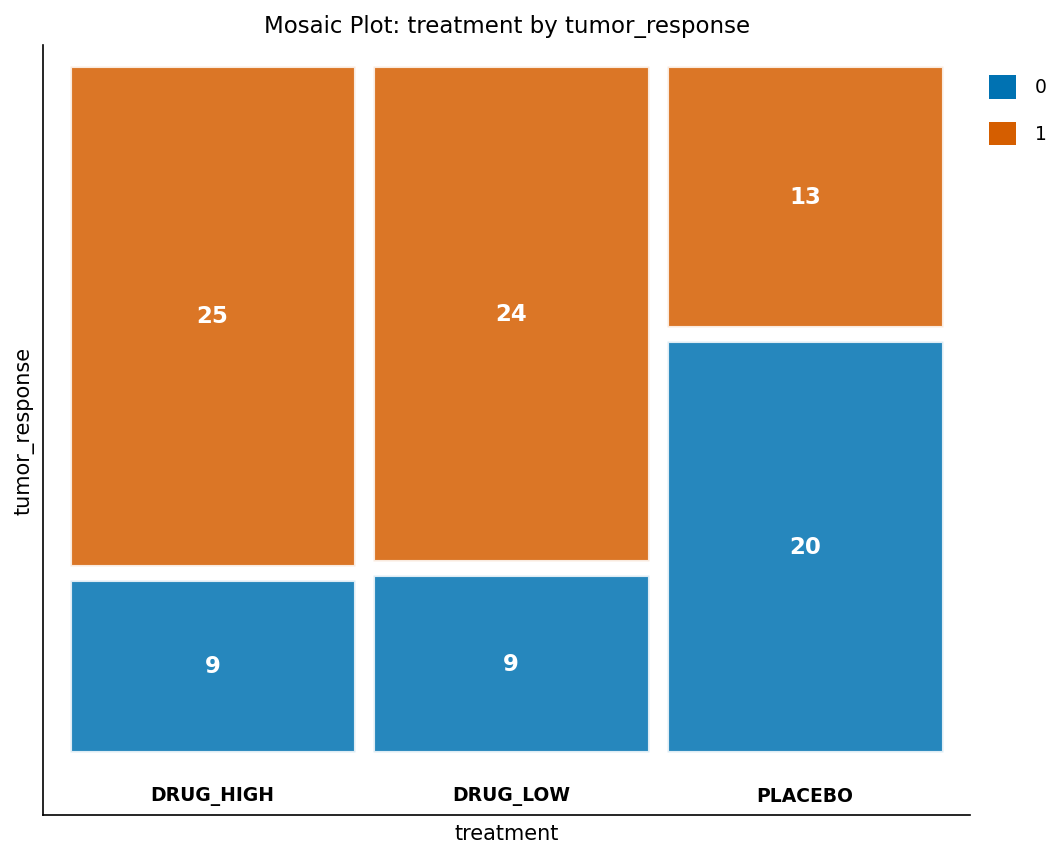

In [3]:
/* --------------------------------------------------------
   Tasso di risposta di base per braccio di trattamento
   -------------------------------------------------------- */
PROCEDURA FREQUENZE DATI=work.trial_patients;
    TABLES treatment * tumor_response / nocol nopercent;
    TITOLO 'Tassi di Risposta Tumorale Osservati per Braccio di Trattamento';
ESEGUIRE;

---

                            Tassi di Risposta Tumorale Osservati per Braccio di Trattamento                             

                            Tassi di Risposta Tumorale Osservati per Braccio di Trattamento                             




NOTE: PROC SQL 

NOTE: Table work.site_rates created.
NOTE: PROC SQL statement used.
NOTE: PROC SGPLOT data=work.site_rates

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


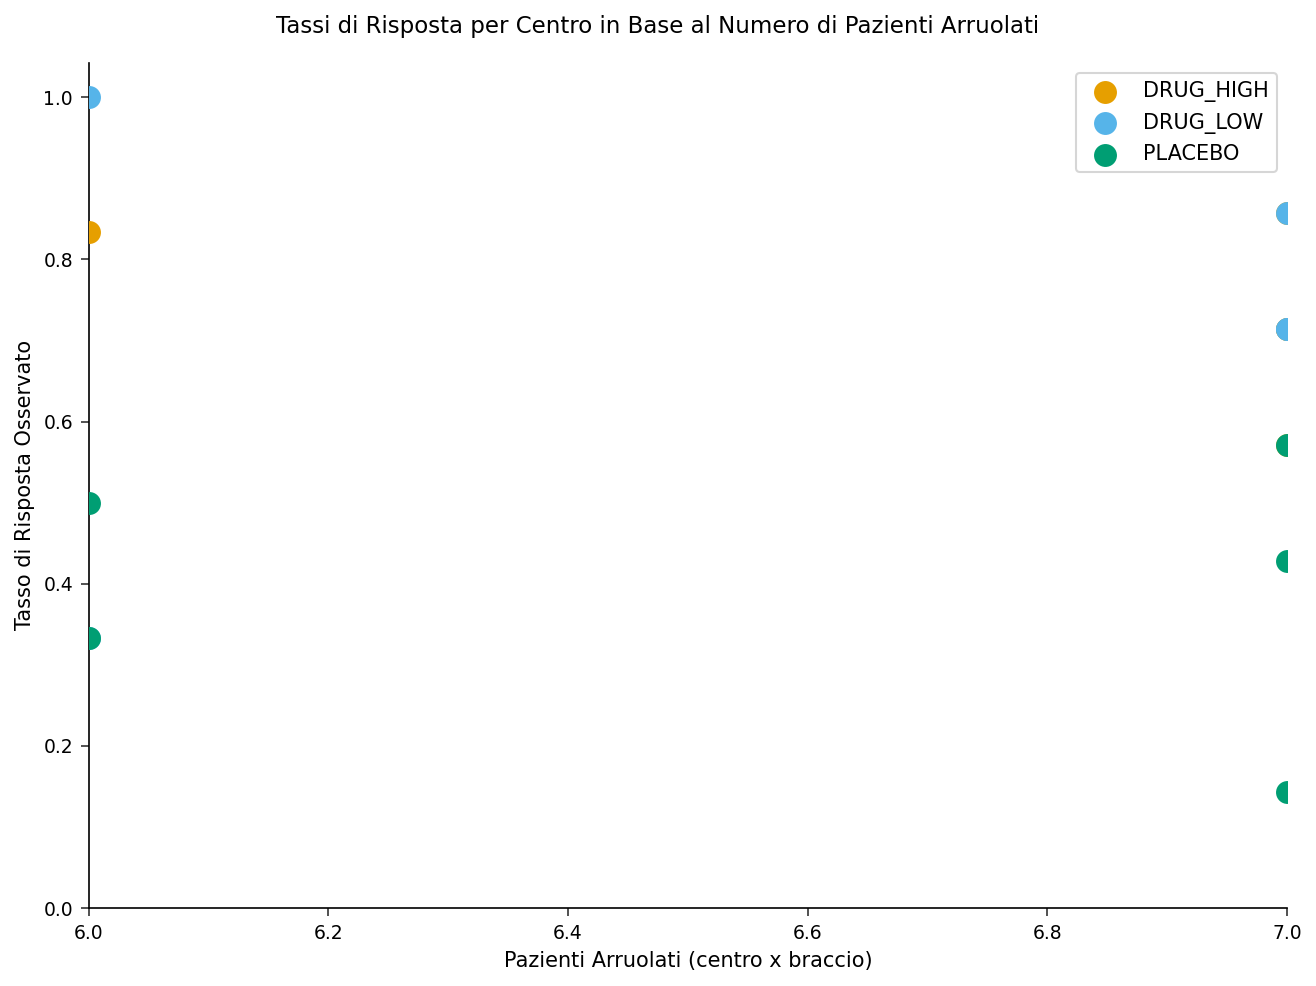

In [4]:
/* --------------------------------------------------------
   Tassi di risposta osservati per centro in base al trattamento.
   Con ~20 pazienti per centro, ogni cella centro-per-braccio
   porta pazienti sufficienti per un tasso osservato stabile.
   -------------------------------------------------------- */
PROCEDURA SQL;
    CREARE TABELLA work.site_rates AS
    SELEZIONARE site_id, treatment,
           count(*) AS n_patients,
           mean(tumor_response) AS response_rate
    FROM work.trial_patients
    GROUP PER site_id, treatment;
QUIT;

PROCEDURA SGPLOT DATI=work.site_rates;
    SCATTER x=n_patients y=response_rate / GROUP=treatment
        MARKERATTRS=(size=10);
    XAXIS ETICHETTA='Pazienti Arruolati (centro x braccio)';
    YAXIS ETICHETTA='Tasso di Risposta Osservato' VALUES=(0 FINO_A 1 PER 0.2);
    TITOLO 'Tassi di Risposta per Centro in Base al Numero di Pazienti Arruolati';
ESEGUIRE;

---

In [5]:
/* --------------------------------------------------------
   Ordina per centro per l'elaborazione di CLASS e RANDOM
   -------------------------------------------------------- */
PROCEDURA ORDINARE DATI=work.trial_patients;
    PER site_id;
ESEGUIRE;


NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Adatta il modello lineare generalizzato misto.
   DIST=BINARY, LINK=LOGIT, intercetta casuale per centro.
   ODS OUTPUT cattura la soluzione degli effetti fissi, la
   stima del parametro di covarianza, e le LSMEANS così
   i passi a valle possono leggere quantità adattate reali.
   -------------------------------------------------------- */
ODS USCITA parameterestimates = work.glmx_fixed
           covparms          = work.glmx_covparms
           LSMEANS           = work.glmx_lsmeans;

PROCEDURA GLIMMIX DATI=work.trial_patients;
    CLASSE treatment(REF='PLACEBO') site_id;
    MODELLO tumor_response(EVENT='1') =
          treatment AGE ecog_score
        / DIST=binary LINK=logit SOLUTION;
    RANDOM INTERCEPT / SUBJECT=site_id SOLUTION;
    LSMEANS treatment / odds ILINK cl;
    ETICHETTA treatment='Trattamento' AGE='Età' ecog_score='Punteggio ECOG'
          site_id='Centro' tumor_response='Risposta Tumorale';
    TITOLO 'GLIMMIX: Endpoint di Efficacia Binario - Sperimentazione di Fase III Multicentrica';
ESEGUIRE;

ODS USCITA CLOSE;

/* --------------------------------------------------------
   Odds ratio di trattamento dalla soluzione degli effetti fissi.
   exp(estimate) converte ciascun coefficiente logit (rispetto al
   riferimento PLACEBO) in un odds ratio con un IC di Wald.
   -------------------------------------------------------- */
DATI work.treatment_or;
    IMPOSTARE work.glmx_fixed;
    DOVE INDEX(Effect, 'treatment') > 0;
    LUNGHEZZA arm $12;
    SE_COND INDEX(Effect, 'DRUG_HIGH') > 0 ALLORA arm = 'DRUG_HIGH';
    ALTRIMENTI arm = 'DRUG_LOW';
    odds_ratio = EXP(STIMA);
    or_lower   = EXP(STIMA - 1.96 * StdErr);
    or_upper   = EXP(STIMA + 1.96 * StdErr);
    MANTENERE arm STIMA StdErr Probt odds_ratio or_lower or_upper;
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.treatment_or noobs ETICHETTA;
    ETICHETTA arm='Braccio vs Placebo' STIMA='Coefficiente Logit'
          Probt='Pr > |t|' odds_ratio='Odds Ratio'
          or_lower='OR Limite Inf. 95%' or_upper='OR Limite Sup. 95%';
    TITOLO 'Odds Ratio di Trattamento vs Placebo';
    FORMATO STIMA StdErr 7.4 Probt 7.4
           odds_ratio or_lower or_upper 7.3;
ESEGUIRE;

                            Tassi di Risposta Tumorale Osservati per Braccio di Trattamento                             

     The GLIMMIX Procedure      
       Model Information        

Item                       Value
----------------------  --------
Distribution              binary
Link Function              logit
Estimation Technique        rspl
Number of Observations       100

       Number of Observations        

Description                     Value
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  site_id     0.2964

                                                Least Squares Means                                                 

Trattamento  Estimate      Mean  Std Error        DF   t Value  Pr > |t|     Lower     Upper  Lower Mean  Upper Mean
-----------  --------  --------  ---------  --------  --------


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> glmx_fixed
NOTE: ODS OUTPUT: COVPARMS -> glmx_covparms
NOTE: ODS OUTPUT: LSMEANS -> glmx_lsmeans
NOTE: PROC GLIMMIX data=work.trial_patients

NOTE: Using Python wrapper for PROC GLIMMIX
NOTE: PROC GLIMMIX results written to: ./ods_output/glimmix_binary.spec.json
NOTE: ODS OUTPUT: ParameterEstimates written to 'glmx_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'glmx_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'glmx_lsmeans'.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: DATA work.treatment_or


NOTE: Read 5 rows from work.glmx_fixed.
NOTE: Wrote work.treatment_or (2 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.treatment_or

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


                                Probabilità di Risposta Prevista dal Modello per Braccio                                

treatment   Probabilità di Risposta Prevista  Responder Previsto
DRUG_HIGH                              0.752                   1
DRUG_LOW                               0.743                   1
PLACEBO                                0.401                   0

                                       Tabella di Concordanza di Classificazione                                        

                                                   The FREQ Procedure

Table of tumor_response by pred_responder

tumor_response |         0 |         1 |      Total
---------------+-----------+-----------+-----------
0              |        20 |        18 |         38
               |     20.00 |     18.00 |      38.00
---------------+-----------+-----------+-----------
1              |        13 |        49 |         62
               |     13.00 |     49.00 |      62.00
---------------+-


NOTE: DATA work.arm_predicted


NOTE: Read 3 rows from work.glmx_lsmeans.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.arm_predicted

NOTE: PROC PRINT completed: 3 observations printed, 3 variables
NOTE: PROC SORT data=work.arm_predicted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 3 rows from work.arm_predicted.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.patients_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.scored_patients

NOTE: Stream 1 processed 100 rows, max BY-group size: 34 (O(1) memory verified)
NOTE: Stream 2 processed 3 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.scored_patients (100 rows, 11 colum

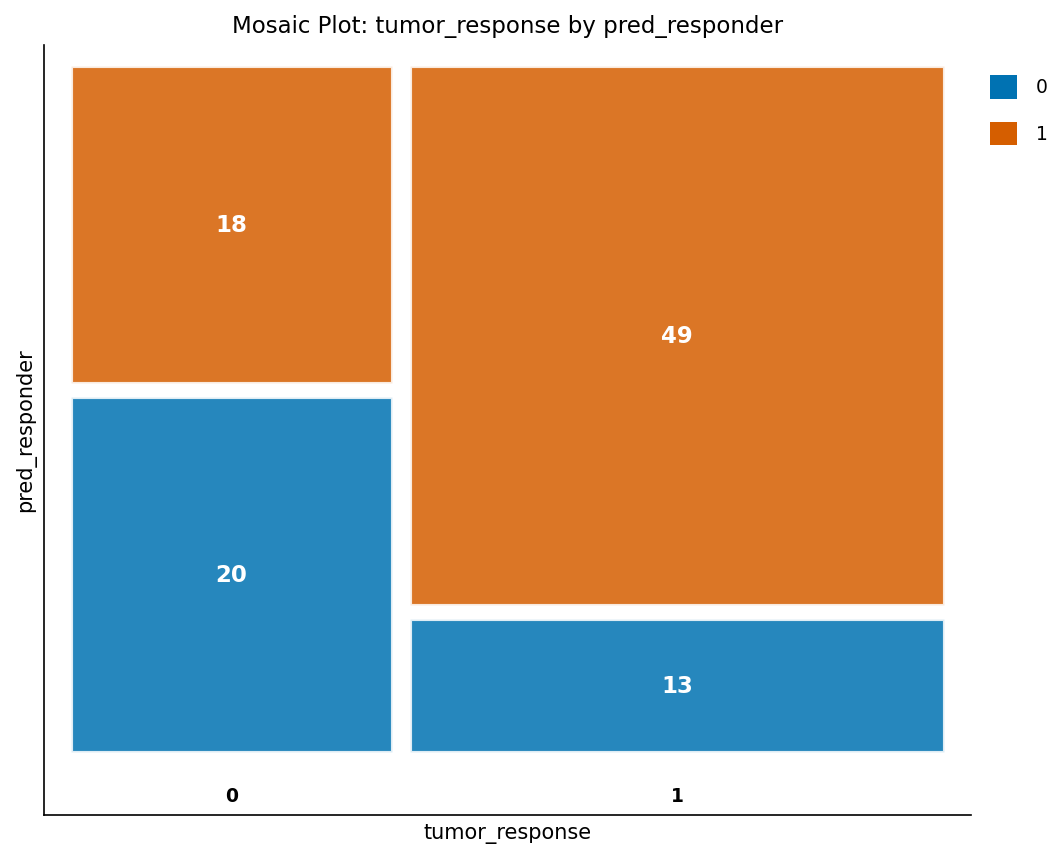

In [7]:
/* --------------------------------------------------------
   Concordanza di classificazione usando la probabilità di risposta
   prevista dal modello per braccio. La stima LSMEANS è sulla scala
   logit; la logit inversa la converte in una probabilità prevista,
   e una soglia di 0.50 segna i responder.
   Questo classifica i pazienti a partire dal modello adattato, non
   da una formula scritta a mano.
   -------------------------------------------------------- */
DATI work.arm_predicted;
    IMPOSTARE work.glmx_lsmeans;
    pred_prob = 1 / (1 + EXP(-STIMA));
    pred_responder = (pred_prob >= 0.50);
    RINOMINARE Level = treatment;
    MANTENERE Level pred_prob pred_responder;
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.arm_predicted noobs ETICHETTA;
    ETICHETTA pred_prob='Probabilità di Risposta Prevista'
          pred_responder='Responder Previsto';
    FORMATO pred_prob 6.3;
    TITOLO 'Probabilità di Risposta Prevista dal Modello per Braccio';
ESEGUIRE;

PROCEDURA ORDINARE DATI=work.arm_predicted; PER treatment; ESEGUIRE;
PROCEDURA ORDINARE DATI=work.trial_patients out=work.patients_sorted; PER treatment; ESEGUIRE;

DATI work.scored_patients;
    UNIRE work.patients_sorted(IN=a) work.arm_predicted;
    PER treatment;
    SE_COND a;
ESEGUIRE;

PROCEDURA FREQUENZE DATI=work.scored_patients;
    TABLES tumor_response * pred_responder / nocol norow;
    TITOLO 'Tabella di Concordanza di Classificazione';
ESEGUIRE;

---

### Interpretazione

Il modello GLIMMIX con intercetta casuale di centro mostra un effetto di trattamento statisticamente significativo per entrambi i bracci attivi rispetto al placebo. Il braccio a dose alta presenta un odds ratio di 4,52 (IC 95% 1,49-13,71), p = 0,0090, e il braccio a dose bassa un odds ratio di 4,32 (IC 95% 1,40-13,30), p = 0,0124, entrambi stimati dalla soluzione degli effetti fissi. Le medie dei minimi quadrati collocano la probabilità di risposta prevista al 75% per la dose alta, 74% per la dose bassa, e 40% per il placebo. La componente di varianza a livello di centro è stimata a 0,296, che si traduce in una correlazione intraclasse di circa 0,08 sulla scala logit latente (usando la varianza residua logistica standard di pi-quadro/3); circa l'8% della variazione latente nella risposta risiede a livello di centro, supportando la specificazione a intercetta casuale rispetto a un adattamento a soli effetti fissi aggregato. Lo stato prestazionale ECOG è una covariata rilevante (coefficiente -0,69, p = 0,0211): ogni incremento di un punto nel punteggio ECOG riduce all'incirca a metà le probabilità di risposta. La tabella di concordanza di classificazione raggiunge un'accuratezza complessiva vicina al 69%, con una sensibilità di circa il 79% guidata dai due bracci attivi e una specificità più bassa (circa 53%) perché l'elevata risposta di base in questa coorte rende più difficile distinguere i non responder.

PROC GLIMMIX in questa build non emette ancora la tabella di inferenza COVTEST né cattura la soluzione BLUP degli effetti casuali (SOLUTIONR) in un dataset, quindi il notebook riporta la componente di varianza come una stima puntuale piuttosto che come un test di ipotesi formale di varianza nulla, e deriva gli odds ratio dalla soluzione degli effetti fissi piuttosto che da una tabella ESTIMATE...EXP. Le conclusioni sostanziali - effetti di trattamento significativi e una componente di varianza di centro non trascurabile - si basano interamente su valori che la procedura produce effettivamente.

---

In [8]:
/* --------------------------------------------------------
   Esporta gli output del modello per il clinical study report.
   Vengono esportati solo i dataset popolati dalla procedura, così
   ogni file arriva con contenuto realmente adattato.
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.glmx_lsmeans
    OUTFILE='trial_lsmeans_by_treatment.csv'
    DBMS=csv REPLACE;
ESEGUIRE;

PROCEDURA EXPORT DATI=work.treatment_or
    OUTFILE='trial_treatment_odds_ratios.csv'
    DBMS=csv REPLACE;
ESEGUIRE;

PROCEDURA EXPORT DATI=work.glmx_covparms
    OUTFILE='trial_site_variance.csv'
    DBMS=csv REPLACE;
ESEGUIRE;


NOTE: PROC EXPORT data=work.glmx_lsmeans outfile=trial_lsmeans_by_treatment.csv

NOTE: Exported 3 rows to trial_lsmeans_by_treatment.csv.
NOTE: PROC EXPORT data=work.treatment_or outfile=trial_treatment_odds_ratios.csv

NOTE: Exported 2 rows to trial_treatment_odds_ratios.csv.
NOTE: PROC EXPORT data=work.glmx_covparms outfile=trial_site_variance.csv

NOTE: Exported 1 rows to trial_site_variance.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>